In [1]:
## IMPORTS ##

import os
import random
from datetime import datetime, timedelta

! pip install pytorch-lightning
import pytorch_lightning as pl
from pytorch_lightning.profilers import PyTorchProfiler
from torch.profiler import schedule

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedShuffleSplit

import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import StratifiedShuffleSplit

!pip install optuna
import optuna


from pytorch_lightning.profilers.pytorch import ScheduleWrapper
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

import json

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.3 MB/s eta 0:00:00


In [2]:
#reproducibilty

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

pl.seed_everything(SEED, workers=True)


# Device configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cpu


In [3]:
df_activity = pd.read_csv('new_activity_data.csv')
df_daily = pd.read_csv('new_daily_data.csv')
df_athlete = pd.read_csv('new_athlete_data.csv')


df_activity['date'] = pd.to_datetime(df_activity['date'], errors='coerce')
df_daily['date'] = pd.to_datetime(df_daily['date'], errors='coerce')


# Calculating the load_size and hr_size
df_activity['load_size'] = df_activity['intensity_factor'] * df_activity['duration_minutes']
df_activity['hr_size'] = df_activity['avg_hr'] * df_activity['duration_minutes']


# Grouping by athlete and date inorder to merge same-day rows together
activity_daily = df_activity.groupby(['athlete_id', 'date']).agg({ 'duration_minutes': 'sum','load_size': 'sum','hr_size': 'sum'}).reset_index()


# getting the averages back
dura_min = activity_daily['duration_minutes'].replace(0, np.nan)
activity_daily['intensity_factor'] = activity_daily['load_size'] / dura_min
activity_daily['avg_hr'] = activity_daily['hr_size'] / dura_min
activity_daily[['intensity_factor','avg_hr']] = activity_daily[['intensity_factor','avg_hr']].fillna(0)


activity_daily = activity_daily.drop(columns=['load_size', 'hr_size'])

In [4]:
dup_daily = df_daily.duplicated(subset=['athlete_id', 'date']).sum()
print("df_daily duplicate athlete-date rows:", dup_daily)


df_daily duplicate athlete-date rows: 0


In [5]:
# combining files to form a single main one #


# adding information that are daily and is pattern followed
main_df = pd.merge(df_daily, activity_daily, on=['athlete_id', 'date'], how='left')


# adding fixed athlete information to main_df such as age and athlete_id
main_df = pd.merge(main_df, df_athlete[['athlete_id', 'age']], on='athlete_id', how='left')

In [6]:
# handling gaps in data like rest days where no data entries #

main_df['duration_minutes'] = main_df['duration_minutes'].fillna(0)

main_df['intensity_factor'] = main_df['intensity_factor'].fillna(0)

main_df['avg_hr'] = main_df['avg_hr'].fillna(0)

#sorting by athlete_id and date
main_df = main_df.sort_values(by=['athlete_id', 'date']).reset_index(drop=True)

In [7]:
## The rolling baseline ##

days = 10

main_df['base_hrv'] = (main_df.groupby('athlete_id')['hrv'].transform(lambda x: x.shift(1).rolling(days, min_periods=1).mean()))

main_df['base_fatigue'] = (main_df.groupby('athlete_id')['fatigue_score'].transform(lambda x: x.shift(1).rolling(days, min_periods=1).mean()))

main_df["base_hrv"] = main_df["base_hrv"].fillna(main_df["hrv"])
main_df["base_fatigue"] = main_df["base_fatigue"].fillna(main_df["fatigue_score"])

main_df["hrv_d"] = (main_df["base_hrv"] - main_df["hrv"]).fillna(0.0)
main_df["fatigue_increase"] = (main_df["fatigue_score"] - main_df["base_fatigue"]).fillna(0.0)


check_cols = [
    "duration_minutes", "intensity_factor", "avg_hr",
    "hrv", "sleep_hours", "fatigue_score", "age",
    "hrv_d", "fatigue_increase"
]

bad_mask = ~np.isfinite(main_df[check_cols].to_numpy(dtype=np.float64))
if bad_mask.any():
    bad_rows, bad_cols = np.where(bad_mask)
    first_r = int(bad_rows[0])
    first_c = check_cols[int(bad_cols[0])]
    raise ValueError(
        f"Non-finite value found in main_df BEFORE target creation. "
        f"Row={first_r}, col='{first_c}', athlete_id={main_df.loc[first_r,'athlete_id']}, "
        f"date={main_df.loc[first_r,'date']}, value={main_df.loc[first_r, first_c]}"
    )



In [34]:
## the target creation function to have the low/medium or high risk to the dataset ##

main_df["risk_score"] = (
    0.60 * np.maximum(main_df["fatigue_increase"], 0) +
    0.35 * np.maximum(main_df["hrv_d"], 0) +
    0.05 * np.maximum(main_df["duration_minutes"] - 30, 0)
  )


# use smoothed score for labeling
def quantile_labels_per_athlete(s):
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)
    return np.where(s >= q2, 2, np.where(s >= q1, 1, 0))

# make labels using per-athlete quantiles (removes athlete baseline bias)
def quantile_labels_per_athlete(s):
    # s is risk_score series for one athlete
    q1 = s.quantile(0.33)
    q2 = s.quantile(0.66)
    return np.where(s >= q2, 2, np.where(s >= q1, 1, 0))


#usinng smooth score for labelling
SMOOTH_DAYS = 3
main_df["risk_score_smooth"] = (
     main_df.groupby('athlete_id')['risk_score']
     .transform(lambda s: s.shift(1).rolling(SMOOTH_DAYS, min_periods=1).mean())
     .fillna(main_df["risk_score"])
   )

main_df["risk_level"] = (
     main_df.groupby('athlete_id')['risk_score_smooth']
     .transform(quantile_labels_per_athlete)
     .astype(int)
   )


print(main_df["risk_level"].value_counts(normalize=True))
print(main_df.groupby('athlete_id')['risk_level'].value_counts(normalize=True).head(20))


risk_level
2    0.342308
0    0.330769
1    0.326923
Name: proportion, dtype: float64
athlete_id  risk_level
a043803765  2             0.342308
            0             0.330769
            1             0.326923
a063817255  2             0.342308
            0             0.330769
            1             0.326923
a067920001  2             0.342308
            0             0.330769
            1             0.326923
a076343185  2             0.342308
            0             0.330769
            1             0.326923
a089250953  2             0.342308
            0             0.330769
            1             0.326923
a092135914  2             0.342308
            0             0.330769
            1             0.326923
a094177347  2             0.342308
            0             0.330769
Name: proportion, dtype: float64


In [9]:
print(main_df.groupby("risk_level")[["hrv_d","fatigue_increase","duration_minutes"]].mean())
print(main_df["risk_level"].value_counts())


               hrv_d  fatigue_increase  duration_minutes
risk_level                                              
0           0.068382          0.019051         69.171250
1           0.068834          0.045960         69.438024
2           1.293354          0.790323         69.450254
risk_level
2    8010
0    7740
1    7650
Name: count, dtype: int64


In [10]:
## saving the main_df to the final csv file ##


main_df.to_csv('final_processed_data.csv', index=False)
print("Saved in 'final_processed_data.csv'")

Saved in 'final_processed_data.csv'


In [11]:
##  creating datasets ##

df = pd.read_csv('final_processed_data.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')


in_features = ['duration_minutes', 'intensity_factor', 'avg_hr','hrv', 'sleep_hours', 'fatigue_score','age', 'hrv_d', 'fatigue_increase']

out_features = ['risk_level']


#stratified athlete split
athlete_level = df.groupby('athlete_id')['risk_level'].max()
athletes = athlete_level.index.to_numpy()
y = athlete_level.values

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(athletes, y))
trainval_athletes, test_id = athletes[trainval_idx], athletes[test_idx]
y_trainval = y[trainval_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
train_idx, val_idx = next(sss2.split(trainval_athletes, y_trainval))
train_id, val_id = trainval_athletes[train_idx], trainval_athletes[val_idx]


train_df = df[df['athlete_id'].isin(train_id)]
val_df = df[df['athlete_id'].isin(val_id)]
test_df = df[df['athlete_id'].isin(test_id)]

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()


scaler = StandardScaler()

 # hard safety check
for name, d in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    arr = d[in_features].to_numpy(dtype=np.float64)
    if not np.isfinite(arr).all():
        bad = np.argwhere(~np.isfinite(arr))
        r, c = int(bad[0,0]), int(bad[0,1])
        raise ValueError(
            f"Non-finite value in {name}[in_features] BEFORE scaling. "
            f"athlete_id={d.iloc[r]['athlete_id']}, date={d.iloc[r]['date']}, "
            f"feature='{in_features[c]}', value={d.iloc[r][in_features[c]]}"
           )

train_df[in_features] = scaler.fit_transform(train_df[in_features])
val_df[in_features]   = scaler.transform(val_df[in_features])
test_df[in_features]  = scaler.transform(test_df[in_features])

joblib.dump(scaler, 'dl_scaler.pkl')
joblib.dump(in_features, 'dl_feature_columns.pkl')


class injury_dataset(Dataset):

  def __init__(self, dataframe, length=14):

    self.sequences = []
    self.labels = []

    grouped = dataframe.groupby('athlete_id')

    for athlete_id, group in grouped:
      group = group.sort_values('date')

      inputs = group[in_features].values
      targets = group['risk_level'].values

      n = len(inputs)
      if n > length:
          for i in range(0, n - length):
              x_seq = inputs[i : i + length]
              y_lab = targets[i + length]
              self.sequences.append(x_seq)
              self.labels.append(y_lab)




  def __len__(self):
        return len(self.sequences)

  def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        return x,y


SEQ_len = 10

train_dataset = injury_dataset(train_df, length=SEQ_len)
val_dataset = injury_dataset(val_df, length=SEQ_len)
test_dataset = injury_dataset(test_df, length=SEQ_len)


In [12]:
## optuna subset ##

train_dataset_full = train_dataset
val_dataset_full   = val_dataset
test_dataset_full  = test_dataset

MAX_seq = 20000

optuna_train = train_dataset_full
optuna_val   = val_dataset_full

if len(optuna_train) > MAX_seq:
    idx = np.random.choice(len(optuna_train), MAX_seq, replace=False)
    optuna_train = torch.utils.data.Subset(optuna_train, idx)

if len(optuna_val) > int(MAX_seq * 0.3):
    idx = np.random.choice(len(optuna_val), int(MAX_seq * 0.3), replace=False)
    optuna_val = torch.utils.data.Subset(optuna_val, idx)

print("Optuna train sequences:", len(optuna_train))
print("Optuna val sequences:", len(optuna_val))


Optuna train sequences: 15500
Optuna val sequences: 3500


In [13]:
## using lightning for dataloading ##

class injury_risk_data(pl.LightningDataModule):

  def __init__(self,train_dataset,val_dataset, test_datset, batch_size=32 ):
    super().__init__()
    self.train_dataset = train_dataset
    self.val_dataset = val_dataset
    self.test_dataset = test_datset
    self.batch_size = batch_size


  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)


  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)


  def test_dataloader(self):
    return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)


# for optuna
injury_data_optuna = injury_risk_data(optuna_train, optuna_val, test_dataset_full, batch_size=32)

# for final training
injury_data_full = injury_risk_data(train_dataset_full, val_dataset_full, test_dataset_full, batch_size=32)



In [14]:
## check ##

batch_1, batch_2 = next(iter(injury_data_full.train_dataloader()))
print(batch_1.shape)
print(batch_2.shape)

torch.Size([32, 10, 9])
torch.Size([32])


In [15]:
## building the architecture ##

class injury_risk_predictor(nn.Module):
  def __init__(self, input_size=7, num_layers=2, hidden_size=64, dropout=0.3 ):
    super(injury_risk_predictor, self).__init__()

    self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)

    self.fc = nn.Linear(hidden_size, 3)


  def forward(self,x):

    lstm_output, _ = self.lstm(x)

    h_final_layer = lstm_output[:,-1,:]

    output = self.fc(h_final_layer)
    return output

In [16]:
## creating the lightning module ##

class injury_risk_lightning(pl.LightningModule):

  def __init__(self, best_params, c_weights=None):
    super().__init__()

    self.val_preds = []
    self.val_targs = []

    self.save_hyperparameters(ignore=['c_weights'])


    self.model = injury_risk_predictor(input_size=len(in_features),
                                       hidden_size=best_params['hidden_size'],
                                       num_layers=best_params['num_layers'],
                                       dropout=best_params['dropout']
                                       )

    # highlighting medium a bit more
    cw = torch.tensor([1.0, 1.4, 1.0], dtype=torch.float32)
    self.loss_fn = nn.CrossEntropyLoss(weight=cw.to(self.device))

    self.lr = best_params['learning_rate']


    #tracking metrics
    self.train_correct = 0
    self.train_total = 0
    self.val_correct = 0
    self.val_total = 0


  def forward(self,x):
    return self.model(x)


  def training_step(self, batch, batch_idx):
     inputs, targets = batch
     logits = self(inputs)
     loss = self.loss_fn(logits, targets)

     if not torch.isfinite(logits).all():
        raise ValueError("training_step: logits became non-finite (NaN/Inf).")

     if not torch.isfinite(loss):
        raise ValueError("training_step: loss became non-finite (NaN/Inf).")


     predictions = torch.argmax(logits, dim=1)
     self.train_correct += (predictions == targets).sum().item()
     self.train_total += targets.size(0);

     self.log('train_loss', loss, prog_bar=True)
     return loss


  def on_train_epoch_end(self):
    accuracy = (self.train_correct/self.train_total) * 100
    self.log('train_accuracy', accuracy, prog_bar=True)
    self.train_correct = 0
    self.train_total = 0


  def validation_step(self, batch, batch_idx):
    inputs, targets = batch
    logits = self(inputs)
    loss = self.loss_fn(logits, targets)

    predictions = torch.argmax(logits, dim=1)
    self.val_correct += (predictions == targets).sum().item()
    self.val_total += targets.size(0)

    self.val_preds.append(predictions.detach().cpu())
    self.val_targs.append(targets.detach().cpu())


    self.log('val_loss', loss, prog_bar=True)
    return loss


  def on_validation_epoch_end(self):
    accuracy = (self.val_correct/self.val_total) * 100
    self.log('val_accuracy', accuracy, prog_bar=True)
    self.val_correct = 0
    self.val_total = 0

    vp = torch.cat(self.val_preds).numpy()
    vt = torch.cat(self.val_targs).numpy()

    macro_f1 = f1_score(vt, vp, average="macro", labels=[0,1,2], zero_division=0)
    self.log("val_macro_f1", macro_f1, prog_bar=True)

    self.val_preds.clear()
    self.val_targs.clear()


  def test_step(self, batch, batch_idx):
    inputs, targets = batch
    logits = self(inputs)
    loss = self.loss_fn(logits, targets)

    predictions = torch.argmax(logits, dim=1)
    accuracy = (predictions == targets).float().mean() * 100

    self.log('test_loss', loss)
    self.log('test_acc', accuracy)
    return {'predictions': predictions.cpu(), 'targets':targets.cpu()}


  def configure_optimizers(self):
    optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( optimizer, mode='max', factor=0.5, patience=3 )

    return { 'optimizer': optimizer, 'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_macro_f1'}}

In [17]:
print("train_df rows:", len(train_df))
print("val_df rows:", len(val_df))
print("train sequences:", len(train_dataset))
print("val sequences:", len(val_dataset))


train_df rows: 16120
val_df rows: 3640
train sequences: 15500
val sequences: 3500


In [18]:
## hyperparameter optimization ##

def objective(trial):

    hidden_size = trial.suggest_int('hidden_size',32, 128)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

    if num_layers == 1:
        dropout = 0.0

    model = injury_risk_predictor(input_size=len(in_features), hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)

    # getting data loaders from the data module
    train_loader = injury_data_optuna.train_dataloader()
    val_loader = injury_data_optuna.val_dataloader()


    # quick training
    model.train()
    for epoch in range(2):
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()


    #validation macro F1
    model.eval()
    all_p, all_t = [], []

    with torch.no_grad():
      for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_p.extend(preds.cpu().numpy())
            all_t.extend(targets.cpu().numpy())

    score = f1_score(all_t, all_p, average="macro", labels=[0, 1, 2], zero_division=0) * 100.0
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_params = study.best_params
if best_params["num_layers"] == 1:
    best_params["dropout"] = 0.0

print('the best hyperparameters:',best_params)


[I 2026-02-10 11:23:22,776] A new study created in memory with name: no-name-5205599f-db95-492f-ab7d-2e57f3a161b7
[I 2026-02-10 11:23:56,948] Trial 0 finished with value: 78.15899431415218 and parameters: {'hidden_size': 52, 'num_layers': 2, 'dropout': 0.3023527136696942, 'learning_rate': 0.00011986722889901965}. Best is trial 0 with value: 78.15899431415218.
[I 2026-02-10 11:24:09,405] Trial 1 finished with value: 50.48953782926253 and parameters: {'hidden_size': 99, 'num_layers': 1, 'dropout': 0.42172400947629407, 'learning_rate': 3.098506465424653e-05}. Best is trial 0 with value: 78.15899431415218.
[I 2026-02-10 11:24:38,454] Trial 2 finished with value: 43.41863933279144 and parameters: {'hidden_size': 55, 'num_layers': 3, 'dropout': 0.48929685880321894, 'learning_rate': 2.4189323704562556e-05}. Best is trial 0 with value: 78.15899431415218.
[I 2026-02-10 11:25:04,854] Trial 3 finished with value: 41.60208345113174 and parameters: {'hidden_size': 97, 'num_layers': 3, 'dropout': 0.

the best hyperparameters: {'hidden_size': 98, 'num_layers': 2, 'dropout': 0.4552600931340076, 'learning_rate': 0.0009288049168001066}


In [19]:
## check ##
model = injury_risk_predictor(input_size=len(in_features)).to(device)

batch_1, batch_2 = next(iter(injury_data_full.train_dataloader()))
output = model(batch_1.to(device))

print(output.shape)

torch.Size([32, 3])


In [20]:
## training ##


checkpoint_cb = ModelCheckpoint(monitor='val_macro_f1', mode='max', save_top_k=1, filename='injury-lstm-{epoch:02d}-{val_macro_f1:.4f}')
earlystop_cb = EarlyStopping(monitor='val_macro_f1', patience=5, mode='max')


trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=20,
    gradient_clip_val=1.0,
    callbacks=[checkpoint_cb, earlystop_cb]
)

pl_model = injury_risk_lightning(best_params=best_params, c_weights=None)
trainer.fit(pl_model, datamodule=injury_data_full)


# exporting the best checjpoint weights for streamlit
best_path = checkpoint_cb.best_model_path
print("best checkpoint:", best_path)



if not best_path:
    raise ValueError("no best checkpoint was saved. Check modelcheckpoint config.")

#best model
best_model = injury_risk_lightning.load_from_checkpoint(
    best_path,
    best_params=best_params,
    c_weights=None
)

best_model.eval()
best_model.to(device)

best_ckpt = torch.load(best_path, map_location='cpu')

sd = best_ckpt["state_dict"]

clean_sd = {k.replace("model.", ""): v for k, v in sd.items() if k.startswith('model.')}

torch.save(clean_sd, "injury_lstm_state_dict.pt")
print("saved best model weights to injury_lstm_state_dict.pt")

sd_check = torch.load("injury_lstm_state_dict.pt", map_location="cpu")
bad_keys = [k for k, v in sd_check.items() if not torch.isfinite(v).all()]
if bad_keys:
    raise ValueError(f"exported state_dict contains non-finite weights: {bad_keys[:10]}")
print("done check, exported weights are finite")

trainer.test(best_model, datamodule=injury_data_full, ckpt_path='best')


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ injury_risk_predictor │  120 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 120 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 120 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

best checkpoint: /content/lightning_logs/version_0/checkpoints/injury-lstm-epoch=18-val_macro_f1=0.9083.ckpt


INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_0/checkpoints/injury-lstm-epoch=18-val_macro_f1=0.9083.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_0/checkpoints/injury-lstm-epoch=18-val_macro_f1=0.9083.ckpt


saved best model weights to injury_lstm_state_dict.pt
done check, exported weights are finite


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     90.4857177734375      │
│         test_loss         │    0.23077784478664398    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.23077784478664398, 'test_acc': 90.4857177734375}]

In [21]:
## evaluation ##


all_predictions = []
all_labels  = []

best_model.eval()
best_model.to(device)

with torch.no_grad():
    for inputs, targets in injury_data_full.test_dataloader():
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = best_model(inputs)
        preds = torch.argmax(logits, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

In [22]:
from collections import Counter
print("True:", Counter(all_labels))
print("Pred:", Counter(all_predictions))


True: Counter({np.int64(0): 1184, np.int64(1): 1179, np.int64(2): 1137})
Pred: Counter({np.int64(1): 1292, np.int64(2): 1164, np.int64(0): 1044})


In [23]:
## adding the confusion matrix ##

c_m = confusion_matrix(all_labels, all_predictions)
print(c_m)

[[1018  166    0]
 [  26 1069   84]
 [   0   57 1080]]


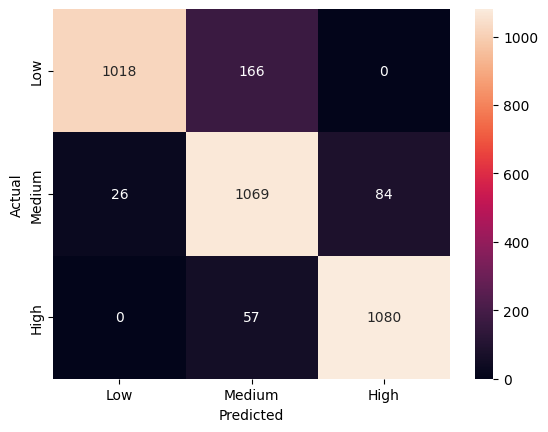

In [24]:
sns.heatmap(c_m, annot=True, fmt='d', xticklabels= ['Low','Medium','High'], yticklabels= ['Low','Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
## classification report ##

print (classification_report(all_labels, all_predictions, target_names=['Low risk', 'Medium risk', 'High risk']))

              precision    recall  f1-score   support

    Low risk       0.98      0.86      0.91      1184
 Medium risk       0.83      0.91      0.87      1179
   High risk       0.93      0.95      0.94      1137

    accuracy                           0.90      3500
   macro avg       0.91      0.91      0.91      3500
weighted avg       0.91      0.90      0.91      3500



In [26]:
## predicting risk trend over time ##

def predict_trend(best_model, dataset, days=10):
  best_model.eval()
  risks =[]

  start = max(0, len(dataset) - days)
  with torch.no_grad():
    for i in range(start, len(dataset)):
      x,_ = dataset[i]
      x = x.unsqueeze(0).to(device)
      logits = best_model(x)
      prediction = torch.argmax(logits, dim=1).item()
      risks.append(prediction)

  return risks


  risks_map = {0: 'Low', 1: 'Medium', 2: 'High'}

In [27]:
## function to predict confidence percentage ##

def predicting_confidence(best_model, inputs, device='cpu'):
    best_model.eval()

    with torch.no_grad():
      inputs = torch.tensor(inputs, dtype=torch.float32).unsqueeze(0).to(device)
      logits = best_model(inputs)
      probabilities = torch.softmax(logits, dim=1)[0]
      conf,prediction = torch.max(probabilities, dim=0)

    return int(prediction.item()), float(conf.item()), probabilities.cpu().numpy()

In [28]:
## helper function to compare last day and weekly average ##

def risk_insight(seq, features):
  info_explain =[]
  last_day =seq[-1]
  two_w_avg =seq.mean(axis=0)

  for i, f in enumerate(features):
    if last_day[i] > two_w_avg[i]:
      info_explain.append(f'{f}, increased recently')
  return info_explain[:3]

In [29]:
## imbalance check ##

df['risk_level'].value_counts(normalize=True)


,proportion
risk_level,
2,0.342308
0,0.330769
1,0.326923


In [30]:
## final saving ##

config = {
    'input_size': len(in_features),
    'hidden_size': best_params["hidden_size"],
    'num_layers': best_params["num_layers"],
    'dropout': best_params["dropout"],
    'len': 10,
    'class_names': ["Low", "Medium", "High"]
}
with open("dl_config.json", "w") as f:
     json.dump(config, f)


In [31]:
## for streamlit ##

def load_model(model_pth="injury_lstm_state_dict.pt", config_pth="dl_config.json", device="cpu"):
    with open(config_pth, 'r') as f:
        config = json.load(f)

    model = injury_risk_predictor(
        input_size=config['input_size'],
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )

    state_dict = torch.load(model_pth, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    return model, config

In [32]:
from collections import Counter
print("Pred distribution:", Counter(all_predictions))
print("True distribution:", Counter(all_labels))


Pred distribution: Counter({np.int64(1): 1292, np.int64(2): 1164, np.int64(0): 1044})
True distribution: Counter({np.int64(0): 1184, np.int64(1): 1179, np.int64(2): 1137})


In [33]:
print(classification_report(all_labels, all_predictions, digits=3))
print("macro f1:", f1_score(all_labels, all_predictions, average="macro"))


              precision    recall  f1-score   support

           0      0.975     0.860     0.914      1184
           1      0.827     0.907     0.865      1179
           2      0.928     0.950     0.939      1137

    accuracy                          0.905      3500
   macro avg      0.910     0.905     0.906      3500
weighted avg      0.910     0.905     0.906      3500

macro f1: 0.9059276994539008
